# ETTV Surrogate Model — Walkthrough
**BPS5231 AI for Sustainable Building Design · Interim 1 (Data + EDA) and first surrogate**

## What is a surrogate model?
A surrogate model (also called a *metamodel* or *emulator*) is a fast ML model trained to imitate a
slower or more cumbersome calculation. You:

1. run the "true" calculation many times on sampled inputs, which gives you a **dataset**
2. train an ML model to map **inputs → output**
3. check it on data it has **never seen**
4. use it where speed matters: design exploration, optimisation, real-time feedback

**Honest framing.** ETTV itself is a cheap formula. This notebook builds the full pipeline on the
formula first, because you can check every step against the exact answer. The research contribution
comes in the final stage, where the "true" calculation becomes a solar simulation of non-standard shading
(SC2), which the BCA tables do not cover well.

## Pipeline
`Define inputs → Sample (LHS) → Calculate ETTV → EDA → Features → Train/test split → Baseline → Models → Evaluate → Interpret`

> ⚠️ `ettv.py` uses **placeholder CF and SC2 values**. Replace them with the BCA code tables before quoting any number.

## 0. Setup
On **Colab**: upload `ettv.py` and `sample.py` using the file panel on the left, or run `!git clone <your repo>`.
Everything used here (numpy, pandas, scipy, scikit-learn, matplotlib) comes preinstalled on Colab.

In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ettv import ETTV_LIMIT, ORIENTATIONS
from sample import lhs_sample, evaluate_row, PARAM_RANGES

# consistent, colour-blind-checked palette
BLUE, ORANGE, AQUA, YELLOW, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "font.size": 10})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
SEED = 42

## 1. Define the design space
Each row of the dataset is one **hypothetical building**: a rectangular box with 4 façades.

| Group | Parameters | Why they're included |
|---|---|---|
| Massing | length, width, storeys, floor height, rotation | set façade areas (the area takeoff) and orientations |
| Façade (per face) | WWR 1–4, overhang ratio R1 1–4 | the main design levers |
| Materials | U_wall, U_fen, SC1 | envelope specification |

The ranges are **assumptions** (see `PARAM_RANGES` in `sample.py`). Tighten them to match your case, e.g. typical Singapore offices.

In [2]:
pd.DataFrame(PARAM_RANGES, index=["min", "max"]).T

,min,max
length_m,20.0,80.0
width_m,20.0,60.0
storeys,5.0,40.0
floor_height_m,3.6,4.2
rotation_deg,0.0,360.0
wwr_1,0.2,0.8
wwr_2,0.2,0.8
wwr_3,0.2,0.8
wwr_4,0.2,0.8
r1_1,0.0,1.0


## 2. Sampling: why Latin Hypercube (LHS)?
Purely random sampling leaves clumps and gaps. A full grid explodes in size: 16 parameters × 10 levels is 10¹⁶ runs.
**LHS** splits every parameter's range into *n* equal slices and uses each slice exactly once, so a modest
number of samples still covers every dimension evenly. It is the standard choice for building-simulation surrogates.

In [3]:
N = 10_000
t0 = time.perf_counter()
X_raw = lhs_sample(N, SEED)
Y_raw = pd.DataFrame([evaluate_row(r) for _, r in X_raw.iterrows()])
df = pd.concat([X_raw, Y_raw], axis=1)
calc_time = time.perf_counter() - t0
Path("data").mkdir(exist_ok=True); df.to_csv("data/ettv_dataset.csv", index=False)
print(f"{N:,} buildings calculated in {calc_time:.1f}s")
df.head()

10,000 buildings calculated in 1.7s


,length_m,width_m,storeys,floor_height_m,rotation_deg,wwr_1,wwr_2,wwr_3,wwr_4,r1_1,...,q_solar,passes,orient_1,ettv_1,orient_2,ettv_2,orient_3,ettv_3,orient_4,ettv_4
0,22.887356,34.614244,36,3.758298,99.104610,0.384021,0.498394,0.665973,0.598212,0.123155,...,77.941758,False,E,80.989977,S,85.262061,W,120.166655,N,68.916401
1,67.456672,50.119745,34,3.905422,56.492709,0.792239,0.678082,0.620906,0.707313,0.004181,...,50.048242,False,NE,93.386735,SE,56.756215,SW,57.632429,NW,62.097038
2,52.914045,21.362518,36,4.011229,256.315323,0.307071,0.678486,0.328540,0.333714,0.586817,...,25.354494,True,W,46.928983,N,51.434568,E,52.768587,S,47.962356
3,76.743905,57.431441,29,3.729360,50.947671,0.298120,0.766658,0.414933,0.607132,0.016443,...,51.234257,False,NE,52.482686,SE,84.442176,SW,56.424133,NW,64.854499
4,66.550192,32.409786,15,3.858342,150.226891,0.523254,0.690667,0.253555,0.208949,0.923277,...,36.772192,True,SE,46.261969,SW,64.831445,NW,37.457006,NE,32.232337


### Check the sampling covered the space
Each input's histogram should look roughly **flat**; that is what LHS promises.

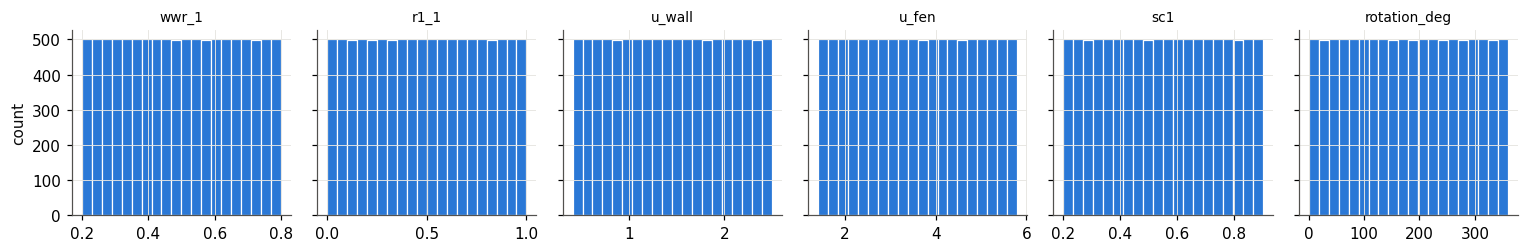

In [4]:
cols = ["wwr_1", "r1_1", "u_wall", "u_fen", "sc1", "rotation_deg"]
fig, axes = plt.subplots(1, len(cols), figsize=(14, 2.4), sharey=True)
for ax, c in zip(axes, cols):
    ax.hist(df[c], bins=20, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.set_title(c, fontsize=9)
axes[0].set_ylabel("count")
plt.tight_layout(); plt.savefig(FIG / "01_input_coverage.png", bbox_inches="tight")

## 3. Exploratory Data Analysis (EDA)
EDA answers: *what does the output look like, what drives it, and is anything odd?*
These are the charts for **Section 4 of your interim report**.

### 3.1 Data quality

In [5]:
print("missing values:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))
df[["ettv", "q_wall", "q_fen", "q_solar"]].describe().round(2)

missing values: 0
duplicate rows: 0


,ettv,q_wall,q_fen,q_solar
count,10000.00,10000.00,10000.00,10000.00
mean,57.17,8.70,6.11,42.36
std,18.46,4.00,2.44,18.14
min,16.08,1.50,1.21,7.75
25%,42.69,5.35,4.11,27.62
50%,55.54,8.43,5.90,40.74
75%,69.79,11.62,7.91,54.68
max,129.64,22.64,14.47,110.44


### 3.2 Distribution of ETTV and the 50 W/m² limit

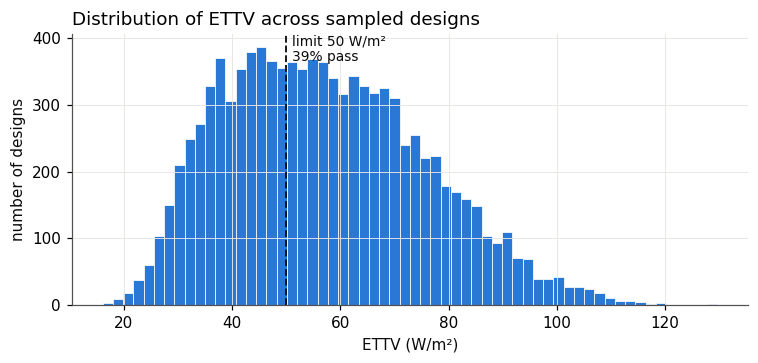

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(df.ettv, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1.2)
ax.text(ETTV_LIMIT + 1, ax.get_ylim()[1] * 0.9, f"limit {ETTV_LIMIT:.0f} W/m²\n{df.passes.mean():.0%} pass", color=INK, fontsize=9)
ax.set_xlabel("ETTV (W/m²)"); ax.set_ylabel("number of designs")
ax.set_title("Distribution of ETTV across sampled designs", loc="left")
plt.tight_layout(); plt.savefig(FIG / "02_ettv_distribution.png", bbox_inches="tight")

### 3.3 Which heat-gain component dominates?
ETTV = wall conduction + glass conduction + **solar**. In Singapore's climate you would expect solar gain
through glass to dominate. That is why SC and shading matter so much, and it is the physical case for your SC2 surrogate.

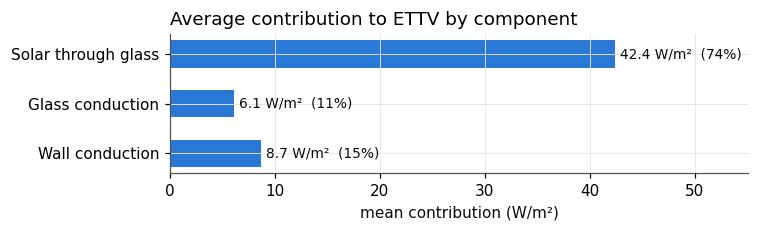

In [7]:
comp = df[["q_wall", "q_fen", "q_solar"]].mean()
share = comp / comp.sum()
fig, ax = plt.subplots(figsize=(7, 2.2))
labels = ["Wall conduction", "Glass conduction", "Solar through glass"]
ax.barh(labels, comp.values, color=BLUE, height=0.55)
for i, (v, s) in enumerate(zip(comp.values, share.values)):
    ax.text(v + 0.5, i, f"{v:.1f} W/m²  ({s:.0%})", va="center", color=INK, fontsize=9)
ax.set_xlim(0, comp.max() * 1.3); ax.set_xlabel("mean contribution (W/m²)")
ax.set_title("Average contribution to ETTV by component", loc="left")
plt.tight_layout(); plt.savefig(FIG / "03_component_share.png", bbox_inches="tight")

### 3.4 Which inputs drive ETTV? (rank correlation)
Spearman correlation measures how consistently ETTV rises or falls with each input. It is a quick first look,
but it only captures one variable at a time and misses interactions.

r1_3             -0.104
r1_4             -0.099
r1_1             -0.095
r1_2             -0.079
floor_height_m   -0.005
rotation_deg     -0.005
width_m          -0.003
length_m          0.002
storeys           0.006
u_fen             0.103
wwr_4             0.157
wwr_2             0.157
wwr_3             0.177
wwr_1             0.194
u_wall            0.205
sc1               0.861
Name: ettv, dtype: float64

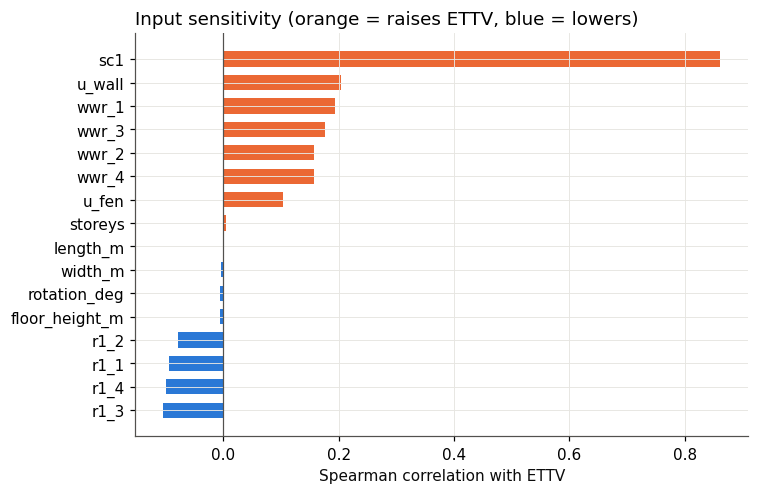

In [8]:
inputs = list(PARAM_RANGES)
corr = df[inputs + ["ettv"]].corr(method="spearman")["ettv"].drop("ettv").sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(corr.index, corr.values, color=[ORANGE if v > 0 else BLUE for v in corr.values], height=0.65)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_xlabel("Spearman correlation with ETTV")
ax.set_title("Input sensitivity (orange = raises ETTV, blue = lowers)", loc="left")
plt.tight_layout(); plt.savefig(FIG / "04_spearman.png", bbox_inches="tight")
corr.round(3)

**What to notice:** `storeys` and `floor_height_m` come out at ≈ 0. Height scales every façade equally, so it cancels
out of the area-weighted average. A good surrogate should learn to ignore those two inputs, and we check that in §7.

### 3.5 Orientation effect
Here we reshape the data so each row is one façade, then compare façade ETTV by orientation.

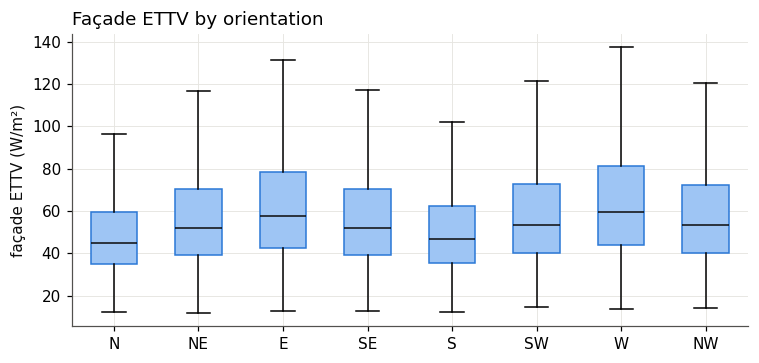

In [9]:
long = pd.concat([pd.DataFrame({"orientation": df[f"orient_{i}"], "ettv_facade": df[f"ettv_{i}"]}) for i in range(1, 5)])
data = [long.loc[long.orientation == o, "ettv_facade"] for o in ORIENTATIONS]
fig, ax = plt.subplots(figsize=(7, 3.4))
bp = ax.boxplot(data, tick_labels=ORIENTATIONS, patch_artist=True, showfliers=False, widths=0.55,
                medianprops=dict(color=INK))
for p in bp["boxes"]: p.set(facecolor="#9ec5f4", edgecolor=BLUE)
ax.set_ylabel("façade ETTV (W/m²)"); ax.set_title("Façade ETTV by orientation", loc="left")
plt.tight_layout(); plt.savefig(FIG / "05_orientation.png", bbox_inches="tight")

### 3.6 Glazing ratio vs ETTV, coloured by glass SC1

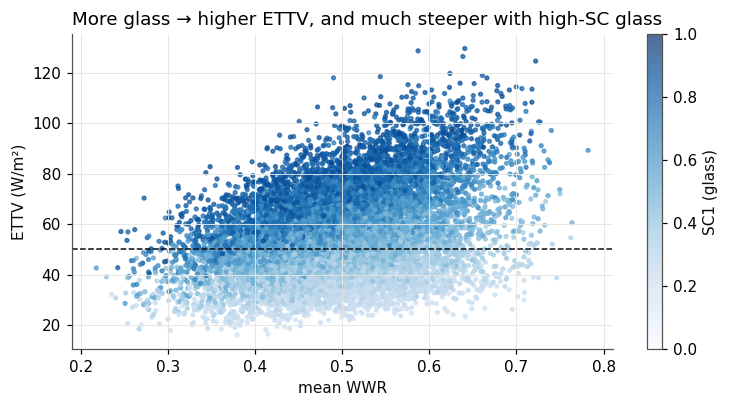

In [10]:
df["wwr_mean"] = df[["wwr_1", "wwr_2", "wwr_3", "wwr_4"]].mean(axis=1)
fig, ax = plt.subplots(figsize=(7, 3.8))
s = ax.scatter(df.wwr_mean, df.ettv, c=df.sc1, cmap="Blues", s=6, alpha=0.7, vmin=0, vmax=1)
ax.axhline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1)
cb = plt.colorbar(s, ax=ax); cb.set_label("SC1 (glass)")
ax.set_xlabel("mean WWR"); ax.set_ylabel("ETTV (W/m²)")
ax.set_title("More glass → higher ETTV, and much steeper with high-SC glass", loc="left")
plt.tight_layout(); plt.savefig(FIG / "06_wwr_vs_ettv.png", bbox_inches="tight")

**What to notice:** the spread fans out as WWR rises. That is an **interaction** (WWR × SC1): the solar term
is `211·WWR·CF·SC`, a product. Pure linear models struggle with products, which is a hint for the modelling step.

### 3.7 Rotation, a circular variable
0° and 360° are the same direction, but a model sees them as far apart numbers. We will fix that in the next section.

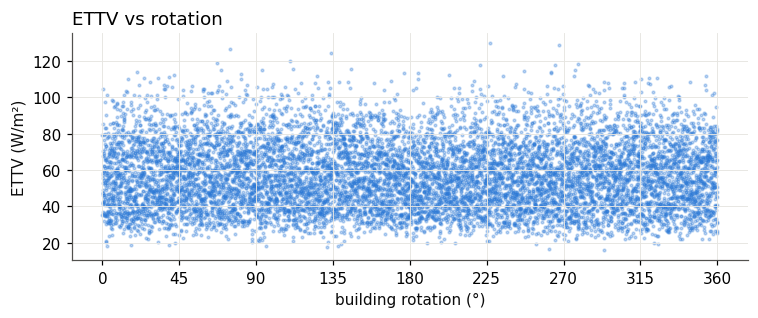

In [11]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(df.rotation_deg, df.ettv, s=3, alpha=0.3, color=BLUE)
ax.set_xlabel("building rotation (°)"); ax.set_ylabel("ETTV (W/m²)"); ax.set_xticks(range(0, 361, 45))
ax.set_title("ETTV vs rotation", loc="left")
plt.tight_layout(); plt.savefig(FIG / "07_rotation.png", bbox_inches="tight")

## 4. Feature engineering
Features are the columns the model is allowed to see.

* **Circular encoding:** replace `rotation_deg` with `sin` and `cos` of the angle, so 359° and 1° end up close together.
* **Aspect ratio:** `length/width` captures façade area weighting in one number.
* **⚠️ Data leakage:** never feed the model columns computed *from* the answer (`q_wall`, `q_solar`, `ettv_1..4`,
  `passes`, `orient_*`). They would make the model look perfect while being useless in practice.

In [12]:
def make_features(d):
    F = d[inputs].copy()
    rad = np.deg2rad(F.pop("rotation_deg"))
    F["rot_sin"], F["rot_cos"] = np.sin(rad), np.cos(rad)
    F["aspect"] = d.length_m / d.width_m
    return F

X = make_features(df); y = df.ettv.values
print(X.shape); list(X.columns)

(10000, 18)


['length_m',
 'width_m',
 'storeys',
 'floor_height_m',
 'wwr_1',
 'wwr_2',
 'wwr_3',
 'wwr_4',
 'r1_1',
 'r1_2',
 'r1_3',
 'r1_4',
 'u_wall',
 'u_fen',
 'sc1',
 'rot_sin',
 'rot_cos',
 'aspect']

## 5. Train / validation / test split
* **Train (70%)**: the model learns from this.
* **Validation (15%)**: used to compare models and tune them.
* **Test (15%)**: locked away and used **once** at the end. This is your honest reported score.

If you tune against the test set, your reported accuracy is optimistic, which is a common mistake.

In [13]:
from sklearn.model_selection import train_test_split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)
print(len(X_tr), len(X_va), len(X_te))

7000 1500 1500


## 6. Models, from simple to complex
Always start with a **baseline**. If a fancy model can't beat it, you have learnt something useful.

| Model | Idea | Needs scaling? |
|---|---|---|
| Mean predictor | predicts the average ETTV for every design; the "zero skill" line | no |
| Linear regression | weighted sum of the inputs | yes (for interpretation) |
| Random forest | many decision trees, averaged | no |
| Gradient boosting | trees added one at a time, each fixing the previous errors | no |
| Neural net (MLP) | layers of weighted sums with non-linear activations | **yes** |

**Metrics.** MAE is the average error in W/m² and is the easiest to explain. RMSE penalises big misses more.
R² is the share of variance explained, where 1 is perfect. **Pass/fail accuracy** is what a designer actually cares about.

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Mean (baseline)":   DummyRegressor(),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random forest":     RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    "Gradient boosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, random_state=SEED),
    "Neural net (MLP)":  make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1500,
                                        early_stopping=True, random_state=SEED)),
}

def score(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred),
            "pass/fail acc": float(np.mean((y_true <= ETTV_LIMIT) == (y_pred <= ETTV_LIMIT)))}

rows = {}
for name, m in models.items():
    t0 = time.perf_counter(); m.fit(X_tr, y_tr); fit_s = time.perf_counter() - t0
    rows[name] = {**score(y_va, m.predict(X_va)), "train time (s)": fit_s}
results = pd.DataFrame(rows).T
results.round(3)

,MAE,RMSE,R2,pass/fail acc,train time (s)
Mean (baseline),14.993,17.990,-0.001,0.601,0.001
Linear regression,3.249,4.258,0.944,0.942,0.008
Random forest,3.605,4.731,0.931,0.946,10.071
Gradient boosting,1.640,2.252,0.984,0.975,1.346
Neural net (MLP),1.229,1.623,0.992,0.975,3.377


**Reading the table:** every model should clearly beat the mean baseline. Linear regression gets close but
can't capture the WWR × SC products. The MLP and boosting usually come out on top. Pick the best model on
**validation**, then score it **once** on test.

In [15]:
best_name = results["MAE"].idxmin()
best = models[best_name]
test_scores = score(y_te, best.predict(X_te))
print(f"Best on validation: {best_name}")
print("TEST:", {k: round(v, 3) for k, v in test_scores.items()})

Best on validation: Neural net (MLP)
TEST: {'MAE': 1.207, 'RMSE': 1.593, 'R2': 0.993, 'pass/fail acc': 0.98}


### 6.1 Parity plot: predicted vs true

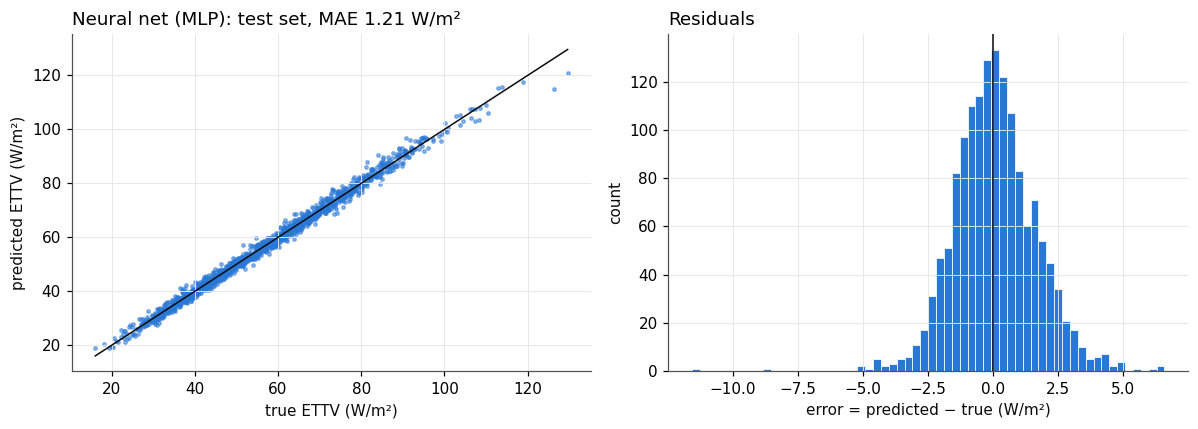

In [16]:
pred = best.predict(X_te)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.scatter(y_te, pred, s=5, alpha=0.5, color=BLUE)
lim = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
ax.plot(lim, lim, color=INK, linewidth=1)
ax.set_xlabel("true ETTV (W/m²)"); ax.set_ylabel("predicted ETTV (W/m²)")
ax.set_title(f"{best_name}: test set, MAE {test_scores['MAE']:.2f} W/m²", loc="left")
ax = axes[1]
ax.hist(pred - y_te, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlabel("error = predicted − true (W/m²)"); ax.set_ylabel("count"); ax.set_title("Residuals", loc="left")
plt.tight_layout(); plt.savefig(FIG / "08_parity.png", bbox_inches="tight")

## 7. Interpretation: what did the model learn?
**Permutation importance** shuffles one feature and measures how much the error grows. If shuffling a
feature makes no difference, the model doesn't use it. `storeys` and `floor_height_m` should come out near zero,
matching the physics from §3.4, which is a good sign the model learnt something real.

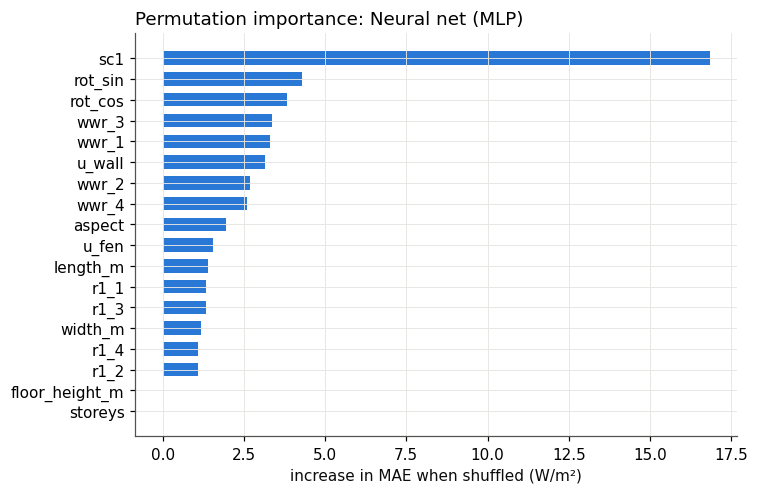

In [17]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(best, X_va, y_va, n_repeats=5, random_state=SEED, scoring="neg_mean_absolute_error")
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(imp.index, imp.values, color=BLUE, height=0.65)
ax.set_xlabel("increase in MAE when shuffled (W/m²)")
ax.set_title(f"Permutation importance: {best_name}", loc="left")
plt.tight_layout(); plt.savefig(FIG / "09_importance.png", bbox_inches="tight")

## 8. How much data do you need? (learning curve)
This is key for the final project: when the "true" calculation becomes a slow solar simulation, each sample costs
minutes, not microseconds. The learning curve tells you roughly how many simulations to budget.

,Linear regression,Gradient boosting,Neural net (MLP)
100,3.87,5.19,6.89
250,3.50,4.23,5.71
500,3.32,3.36,4.60
1000,3.31,2.99,3.29
2500,3.27,2.30,1.98
5000,3.25,1.87,1.59
7000,3.25,1.64,1.23


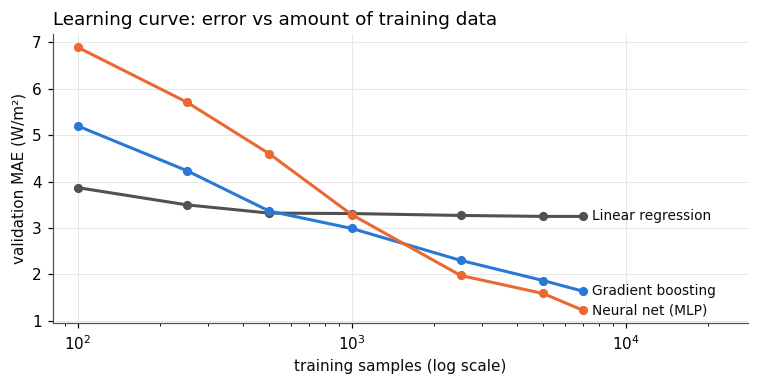

In [18]:
from sklearn.base import clone
sizes = [100, 250, 500, 1000, 2500, 5000, len(X_tr)]
lc = {n: [] for n in ["Linear regression", "Gradient boosting", "Neural net (MLP)"]}
for n in sizes:
    for name in lc:
        m = clone(models[name]).fit(X_tr[:n], y_tr[:n])
        lc[name].append(mean_absolute_error(y_va, m.predict(X_va)))
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, maes), col in zip(lc.items(), [MUTED, BLUE, ORANGE]):
    ax.plot(sizes, maes, marker="o", markersize=5, linewidth=2, color=col)
    ax.annotate(name, (sizes[-1], maes[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("training samples (log scale)"); ax.set_ylabel("validation MAE (W/m²)")
ax.set_title("Learning curve: error vs amount of training data", loc="left")
ax.set_xlim(right=sizes[-1] * 4)
plt.tight_layout(); plt.savefig(FIG / "10_learning_curve.png", bbox_inches="tight")
pd.DataFrame(lc, index=sizes).round(2)

**What to notice:** with only a few hundred samples, **linear regression wins**. Flexible models (the MLP)
need more data before they overtake it. So when data is expensive, simple models and good features
often beat deep learning. That makes a good discussion point in your report.

## 9. Speed check

In [19]:
t0 = time.perf_counter(); best.predict(X_te); surr_s = time.perf_counter() - t0
print(f"Calculator: {calc_time / N * 1e3:.3f} ms per design (Python loop)")
print(f"Surrogate : {surr_s / len(X_te) * 1e3:.4f} ms per design (batched)")

Calculator: 0.168 ms per design (Python loop)
Surrogate : 0.0092 ms per design (batched)


**Be honest in the write-up:** for the pure formula, both are practically instant. The surrogate's value appears
when the ground truth is slow, e.g. a Radiance or EnergyPlus run for complex shading that takes seconds to minutes.

## 10. Next steps toward the final submission
1. **Replace the placeholder CF and SC2 values** in `ettv.py` with the BCA code tables, then re-run everything.
2. **Hyperparameter tuning** on the best model with `GridSearchCV` or Optuna, using cross-validation on train only.
3. **SC2 surrogate:** parameterise a non-standard shading device (fin depth and angle, louvre spacing, and so on),
   simulate its solar reduction with Ladybug Tools or EnergyPlus, and train a surrogate on those results.
4. Feed the SC2 surrogate into the ETTV calculator, which gives you a *hybrid physics + ML* model.
5. **Optimisation demo:** search the surrogate for the cheapest façade that passes 50 W/m².